In [1]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.radnav_stacked_pc_tb import RadnavStackedPCTB
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.plotter_localization import PlotterLocalization
from odometry.plotting.movies import MovieGenerator
from odometry.point_cloud_processing.temporal_pc_stacker import temporalPcStacker


/home/david/.cache/pypoetry/virtualenvs/odometry-JJ4jnFPp-py3.11/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
DATASET_PATH=os.getenv("DATASET_DIRECTORY")
MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")

#setup the datasets
folder_name = "WILK"
# file_name = "WILK_Multipath_Test_1"
# file_name = "WILK_Path_1_No_Dynamic"
file_name = "WILK_Multipath_Test_5"

dataset = radnavDS(
    dataset_path=os.path.join(DATASET_PATH,folder_name,file_name), #_spin_recall
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="wilkinson.yaml"
)

plotter = PlotterLocalization(
    dataset=dataset,
    map_handler=map_handler
)

found 2886 radar samples
found 2886 lidar samples
found 2886 camera samples
found 2886 imu (orientation only) samples
found 2886imu (full data) samples
found 2886 vehicle velocity samples
loaded map from /data/radnav/maps/wilkinson.yaml
loaded map free space from /data/radnav/maps/wilkinson.yaml


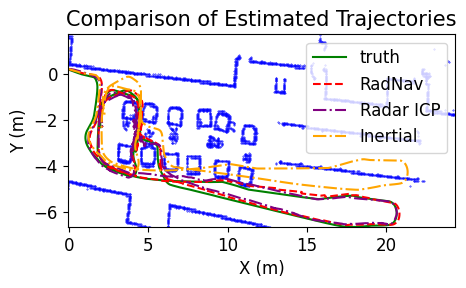

In [3]:
fig,ax = plt.subplots(figsize=(5,2.5))

history = np.load("Trajectories/localization/gt.npy")
ax.plot(
    history[:,0],
    history[:,1],
    color="green",
    linestyle="-",
    label="truth")

history = np.load("Trajectories/localization/radnav.npy")
ax.plot(
    history[:,0],
    history[:,1],
    color="red",
    linestyle="--",
    label="RadNav")

history = np.load("Trajectories/localization/radar_icp_only.npy")
ax.plot(
    history[:,0],
    history[:,1],
    color="purple",
    linestyle="-.",
    label="Radar ICP")

history = np.load("Trajectories/localization/odom_only.npy")
ax.plot(
    history[:,0],
    history[:,1],
    color="orange",
    linestyle="-.",
    label="Inertial")

ax.set_xlim(
    np.min(history[:,0]) - 0,
    np.max(history[:,0]) + 3)
ax.set_ylim(
    np.min(history[:,1]) - 1.6,
    np.max(history[:,1]) + 1.5)
    
ax.set_title("Comparison of Estimated Trajectories",fontsize=plotter.font_size_title)
ax.set_xlabel("X (m)",fontsize=plotter.font_size_axis_labels)
ax.set_ylabel("Y (m)",fontsize=plotter.font_size_axis_labels)
ax.tick_params(labelsize=plotter.font_size_ticks)

#plot the map
ax.scatter(
    plotter.map_handler.map_points[:,0],
    plotter.map_handler.map_points[:,1],
    label="map",
    marker=".",
    s=0.5,
    color="blue")
#show the legend
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[:4],
        labels[:4],
        loc="upper right",
        fontsize=plotter.font_size_legend)

plt.show()
fig.savefig("Trajectories/localization/comparison.png")

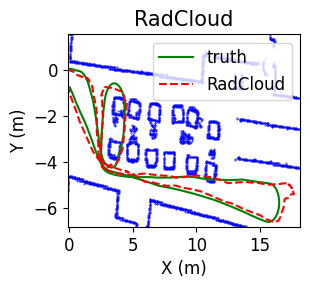

In [4]:
fig,ax = plt.subplots(figsize=(3.0,2.5))

history = np.load("Trajectories/localization/gt_radCloud.npy")
ax.plot(
    history[:,0],
    history[:,1],
    color="green",
    linestyle="-",
    label="truth")

history = np.load("Trajectories/localization/radCloud.npy")
ax.plot(
    history[:,0],
    history[:,1],
    color="red",
    linestyle="--",
    label="RadCloud")

ax.set_xlim(
    np.min(history[:,0]) - 0,
    np.max(history[:,0]) + 0.5)
ax.set_ylim(
    np.min(history[:,1]) - 0.2,
    np.max(history[:,1]) + 1.5)
    
ax.set_title("RadCloud",fontsize=plotter.font_size_title)
ax.set_xlabel("X (m)",fontsize=plotter.font_size_axis_labels)
ax.set_ylabel("Y (m)",fontsize=plotter.font_size_axis_labels)
ax.tick_params(labelsize=plotter.font_size_ticks)

#plot the map
ax.scatter(
    plotter.map_handler.map_points[:,0],
    plotter.map_handler.map_points[:,1],
    label="map",
    marker=".",
    s=0.5,
    color="blue")
#show the legend
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[:2],
        labels[:2],
        loc="upper right",
        fontsize=plotter.font_size_legend)

plt.show()
fig.savefig("Trajectories/comparison.png")

FileNotFoundError: [Errno 2] No such file or directory: 'Trajectories/gt_radarHD.npy'

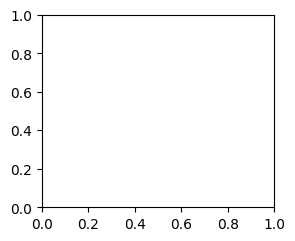

In [5]:
fig,ax = plt.subplots(figsize=(3.0,2.5))

history = np.load("Trajectories/gt_radarHD.npy")
ax.plot(
    history[:,0],
    history[:,1],
    color="green",
    linestyle="-",
    label="truth")

history = np.load("Trajectories/radarHD.npy")
ax.plot(
    history[:,0],
    history[:,1],
    color="red",
    linestyle="--",
    label="RadarHD")

ax.set_xlim(
    np.min(history[:,0]) - 0,
    np.max(history[:,0]) + 0.5)
ax.set_ylim(
    np.min(history[:,1]) - 0,
    np.max(history[:,1]) + 1.5)
    
ax.set_title("RadarHD",fontsize=plotter.font_size_title)
ax.set_xlabel("X (m)",fontsize=plotter.font_size_axis_labels)
ax.set_ylabel("Y (m)",fontsize=plotter.font_size_axis_labels)
ax.tick_params(labelsize=plotter.font_size_ticks)

#plot the map
ax.scatter(
    plotter.map_handler.map_points[:,0],
    plotter.map_handler.map_points[:,1],
    label="map",
    marker=".",
    s=0.5,
    color="blue")
#show the legend
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[:2],
        labels[:2],
        loc="upper right",
        fontsize=plotter.font_size_legend)

plt.show()
fig.savefig("Trajectories/comparison.png")